# Multidimensional Analysis of Care Trajectories: Synthea Dataset

This notebook presents an exploration of the hyperparameters of the SWoTTeD method on a Synthea dataset of medication trajectories (901 patients with chronic diseases, followed for 179 days).

The goal is to identify a configuration that produces both a high-quality reconstruction $\text{FIT}_X$ and clinically interpretable temporal phenotypes.

## Table of Contents

1. Imports and environment setup
2. Loading and preparing the data
3. Initializing the TCA model and constructing the tensor
4. Joint optimization of $R$, $\omega$, $\tilde{\alpha}$, and $\tilde{\gamma}$ using `Optuna`
5. Clustering based on phenotype intensities

The data used were generated by Synthea.

> Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. *Synthea™ Novel coronavirus (COVID-19) model and synthetic data set*. Intelligence-Based Medicine. 2020 Nov;1:100007. [https://doi.org/10.1016/j.ibmed.2020.100007](https://doi.org/10.1016/j.ibmed.2020.100007)

# 1. Imports

In [1]:
from pathlib import Path
import sys
import time
import itertools

import random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn.functional as F

# Loading the TCA package

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "trajectoryclusteringanalysis").exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver la racine du projet depuis {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Package chargé depuis : {src_path}")

Package chargé depuis : c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


### 1.2. Functions

To simplify the rest of the process, we implement the following functions:
- `run_swotted_trial`: a training function for a given configuration, with early stopping and LR scheduling
- `build_results_df`: aggregates the results into a DataFrame sorted by $\text{FIT}_X$ in descending order
- `compute_normalized_reg_terms`: calculates the true values of $\alpha$ and $\gamma$ from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ and the tensor dimensions
- `plot_training_history`: visualizes the training curve in three panels: total loss and $\text{FIT}_X$ (top panel), the contribution of regularization terms to the total loss (middle panel), and the evolution of $\|P\|_1$ and $S(W)$ over the epochs (bottom panel)
- `phenotype_diversity`: calculates the average cosine diversity among the $R$ phenotypes to verify the absence of redundancy

The `compute_normalized_reg_terms` function implements the following normalization:

$$\alpha = \tilde{\alpha} \cdot \frac{K \cdot T \cdot N}{R \cdot N \cdot \omega} \qquad \gamma = \tilde{\gamma} \cdot \frac{K \cdot T \cdot N}{R \cdot T \cdot K}$$

where $\tilde{\alpha}$ and $\tilde{\gamma}$ are dimensionless relative weights that are comparable across configurations regardless of the value of $R$ or $\omega$.

The `plot_training_history` function plots the following together:
- the total loss and the estimated $\text{FIT}_X$ over the course of the epochs (top panel)
- the contribution of each regularization term to the loss (middle panel)
- the $\|P\|_1$ norm of the phenotypes and the non-succession penalty $S(W)$ (bottom panel)

These curves allow us to assess the effect of the regularization terms.

The `phenotype_diversity` function is defined such that, for each pair of phenotypes $(i, j)$, we calculate:

$$d_{\cos}(\mathcal{P}_i, \mathcal{P}_j) = 1 - \frac{\langle \tilde{p}_i, \tilde{p}_j \rangle}{\|\tilde{p}_i\| \cdot \|\tilde{p}_j\|}$$

where $\tilde{p}_r$ is the flattened and normalized vector of the phenotype $\mathcal{P}_r$. The overall diversity is the average over all pairs $(i < j)$:

$$\text{div}(\mathcal{P}) = \binom{R}{2}^{-1} \sum_{1 \leq i < j \leq R} d_{\cos}(\mathcal{P}_i, \mathcal{P}_j)$$

A value close to $0$ indicates nearly identical phenotypes; a value close to $1$ indicates distinctly different phenotypes (maximum diversity).

In [2]:
def run_swotted_trial(
    timed_event_structure: pd.DataFrame,
    rank: int,
    time_window_length: int,
    reg_ns: float,
    reg_s: float,
    lr: float,
    n_epochs: int,
    metric: str = 'Bernoulli',
    early_stopping: bool = True,
    early_stopping_patience: int = 5,
    early_stopping_min_delta: float = 1e-4,
    fit_metric_every_n_epochs: int = 5,
    fit_metric_eval_max_patients: int = 64,
    num_workers: int = 0,
    lr_schedule_type: str = 'reduce_on_plateau',
    lr_rop_factor: float = 0.5,                 
    lr_rop_patience: int = 10,                    
    lr_rop_min_lr: float = 1e-6,                 
) -> dict:
    print('\n' + '=' * 90)
    print(f"rank={rank}, twl={time_window_length}, reg_ns={reg_ns}, "
          f"reg_s={reg_s}, learning_rate={lr}")
    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()
    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank,
        time_window_length,
        reg_ns,
        reg_s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients,
        restore_best_fit_checkpoint=early_stopping,
        num_workers=num_workers,
        early_stopping_patience=early_stopping_patience if early_stopping else None,
        early_stopping_min_delta=early_stopping_min_delta,
        early_stopping_monitor='fit_metric',
        lr_schedule_type=lr_schedule_type,     
        lr_rop_factor=lr_rop_factor,           
        lr_rop_patience=lr_rop_patience,      
        lr_rop_min_lr=lr_rop_min_lr,          
    )
    elapsed = time.perf_counter() - t0
    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit       = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit      = hist.get('final_fit_metric', None)
    epochs_run     = len(hist.get('epoch', []))
    p_l1_values = [v for v in hist.get('p_l1_norm', []) if v is not None]
    ns_values   = [v for v in hist.get('non_succession', []) if v is not None]
    final_p_l1  = p_l1_values[-1] if p_l1_values else None
    final_ns    = ns_values[-1]   if ns_values   else None
    print(f"  best_fit_metric={best_fit:.4f}, final_fit_metric={final_fit:.4f}, "
          f"epochs={epochs_run}, temps={elapsed:.1f}s")
    return {
        'rank':                  rank,
        'time_window_length':    time_window_length,
        'reg_term_ns':           reg_ns,
        'reg_term_s':            reg_s,
        'learning_rate':         lr,
        'epochs_run':            epochs_run,
        'best_fit_metric':       best_fit,
        'best_fit_epoch':        best_fit_epoch,
        'final_fit_metric':      final_fit,
        'final_p_l1_norm':       final_p_l1,       
        'final_non_succession':  final_ns,         
        'elapsed_s':             round(elapsed, 2),
        'tca_trial':             tca_trial,
    }

def build_results_df(results: list) -> pd.DataFrame:
    """Converts a list of results into a DataFrame sorted by best FIT_X in descending order."""
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(
            by=['best_fit_metric', 'final_fit_metric'],
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)
    return df

In [3]:
def compute_normalized_reg_terms(K, T, N, R, omega, alpha_rel=0.5, gamma_rel=0.5):
    """
    Calcule alpha et gamma normalisés par les dimensions du tenseur.
    """
    norm_recon  = K * T * N
    norm_sparse = R * N * omega
    norm_ns     = R * T * K

    alpha = float(alpha_rel * (norm_recon / norm_sparse))
    gamma = float(gamma_rel * (norm_recon / norm_ns))
    return alpha, gamma

In [4]:
def plot_training_history(row, title_suffix=""):
    """Displays the training curve (train_loss + FIT_X + regularization) for a configuration.

    Parameters
    ----------
    row: dict or pd.Series
        Row of the results DataFrame containing `tca_trial` and the metadata.
    title_suffix: str
        Optional suffix added to the graph title.
    """
    tca_trial = row['tca_trial']
    history = getattr(tca_trial.analyzer, 'training_history', None)

    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("No training history available.")

    epochs      = history['epoch']
    train_loss  = history['train_loss_total']
    fit_epochs  = history['fit_metric_points_epoch']
    fit_values  = history['fit_metric_points_value']
    p_l1_values = history.get('p_l1_norm', [])
    ns_values   = history.get('non_succession', [])

    has_reg = any(v is not None for v in p_l1_values) or any(v is not None for v in ns_values)

    if has_reg:
        fig, (ax_top, ax_mid) = plt.subplots(
            2, 1, figsize=(10, 9), sharex=True,
            gridspec_kw={'height_ratios': [3, 2]}
        )
    else:
        fig, ax_top = plt.subplots(figsize=(10, 5))
        ax_mid = None

    # --- Top panel: train_loss + FIT metric ---
    ax_top.plot(epochs, train_loss, color='tab:blue', linewidth=2, label='train_loss_total')
    ax_top.set_ylabel('train_loss_total', color='tab:blue')
    ax_top.tick_params(axis='y', labelcolor='tab:blue')
    ax_top.grid(alpha=0.25)

    ax2 = ax_top.twinx()
    if fit_epochs:
        ax2.plot(fit_epochs, fit_values, color='tab:green',
                 marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0:
                y_offset = 10 if i % 4 == 0 else -15
                ax2.annotate(f"{y:.4f}", (x, y),
                             textcoords='offset points',
                             xytext=(0, y_offset),
                             ha='center', fontsize=9)
        fit_min, fit_max = min(fit_values), max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(fit_min - 0.05 * fit_span, fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')
    lines  = ax_top.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax_top.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax_top.legend(lines, labels, loc='best')

    if has_reg:
        p_l1_clean = [(e, v) for e, v in zip(epochs, p_l1_values) if v is not None]
        ns_clean   = [(e, v) for e, v in zip(epochs, ns_values)   if v is not None]

        alpha_val = float(row.get('reg_term_s', 1.0))
        gamma_val = float(row.get('reg_term_ns', 1.0))

        loss_clean  = [v for v in train_loss if v is not None]
        epochs_loss = [e for e, v in zip(epochs, train_loss) if v is not None]

        # --- Bottom panel (now 2nd panel): Contributions as a percentage of total loss ---
        if ax_mid is not None:
            if p_l1_clean:
                ep, vp = zip(*p_l1_clean)
                loss_interp_p = np.interp(ep, epochs_loss, loss_clean)
                pct_p = [100 * alpha_val * v / l if l > 0 else 0
                         for v, l in zip(vp, loss_interp_p)]
                ax_mid.plot(ep, pct_p, color='darkorange', linewidth=1.5,
                            label=r'\alpha \cdot \|P\|_1$ / loss (%)')

            if ns_clean:
                en, vn = zip(*ns_clean)
                loss_interp_ns = np.interp(en, epochs_loss, loss_clean)
                pct_ns = [100 * gamma_val * v / l if l > 0 else 0
                          for v, l in zip(vn, loss_interp_ns)]
                ax_mid.plot(en, pct_ns, color='darkgreen', linewidth=1.5,
                            linestyle='--', label=r'\gamma \cdot S(W)$ / loss (%)')

            ax_mid.set_ylabel('Contribution à la loss (%)')
            ax_mid.tick_params(axis='y')
            ax_mid.grid(alpha=0.25)
            ax_mid.legend(loc='best')
            ax_mid.set_xlabel('Epoch')
    else:
        ax_top.set_xlabel('Epoch')

    cfg = (f"R={row['rank']}, ω={row['time_window_length']}, "
           f"α={row['reg_term_s']}, γ={row['reg_term_ns']}, "
           f"lr={row['learning_rate']}")
    fig.suptitle(f"Training — {cfg}{(' — ' + title_suffix) if title_suffix else ''}")
    plt.tight_layout()
    plt.show()

In [5]:
def phenotype_diversity(Ph_tensor: torch.Tensor, eps: float = 1e-12):
    """Calculates the average cosine diversity among R phenotypes.

    Parameters
    ----------
    Ph_tensor: torch.Tensor
        Tensor of shape (R, N, w).
    eps: float
        Value for numerical stability during normalization.

    Returns
    -------
    div_value: float
        Average 1-cosine diversity, in [0, 1].
    pairwise_div: torch.Tensor
        Pairwise diversity matrix of shape (R, R), with zeros on the diagonal.
    """
    if not isinstance(Ph_tensor, torch.Tensor):
        Ph_tensor = torch.as_tensor(Ph_tensor, dtype=torch.float32)

    if Ph_tensor.ndim != 3:
        raise ValueError(f"Expected format (R, N, w), received {tuple(Ph_tensor.shape)}")

    R = Ph_tensor.shape[0]
    if R < 2:
        return 0.0, torch.zeros((R, R), dtype=Ph_tensor.dtype, device=Ph_tensor.device)

    # Flattening (N, w) → vector in R^(N*w), then L2 normalization
    P = Ph_tensor.reshape(R, -1).float()
    P = F.normalize(P, p=2, dim=1, eps=eps)

    # Cosine similarity matrix
    cos_sim = P @ P.T

    # Diversity matrice : 1 - cos(P_i, P_j)
    pairwise_div = 1.0 - cos_sim
    pairwise_div.fill_diagonal_(0.0)

    # Average across pairs (i < j)
    upper_idx = torch.triu_indices(R, R, offset=1, device=pairwise_div.device)
    div_value = pairwise_div[upper_idx[0], upper_idx[1]].mean().item()

    return div_value, pairwise_div


def print_diversity(row):
    """Displays the phenotypic diversity and the pairwise matrix for a configuration."""
    tca_trial = row['tca_trial']
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()
    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotypic diversity (mean 1 - cosine) : {div_value:.6f}\n")

    R = pairwise_div.shape[0]
    col_names = [f"Phenotype_{i+1}" for i in range(R)]
    df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )
    display(df)

## 2. Data Loading and Preparation

### 2.1. Loading

The dataset is in long format: each row corresponds to an event for a patient at a given time.
Event types correspond to ten medications covering cardiovascular, respiratory, and metabolic treatments (including Albuterol, Fluticasone, Insulin, Metformin, Hydrochlorothiazide, Amlodipine, Atenolol, Nitroglycerin, and Simvastatin).

In [6]:
df = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")
df['time'] = df['time']

# Dictionary to Simplify the Names of Medications
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df['medication_events'] = df['medication_events'].map(medication_mapping)


print(f"Number of patients : {df['patient_id'].nunique()}")
print(f"Maximum follow-up time (days) : {df['time'].max()}")
df.head()

Number of patients : 901
Maximum follow-up time (days) : 179


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,22,Fluticasone Inhaler
3,1,22,Albuterol Inhaler
4,1,35,Fluticasone Inhaler


### 2.2. Event Encoding

Event labels are encoded as integers to be passed to the TCA model. We retain `event_names` for visualizations.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
name_events = label_encoder.classes_

timed_event_structure.head()

,ID_PATIENT,Time,Event
0,1,11,3
1,1,11,0
2,1,22,3
3,1,22,0
4,1,35,3


### 2.3. Descriptive Statistics

In [8]:
n_patients = timed_event_structure['ID_PATIENT'].unique()
n_events   = timed_event_structure['Event'].unique()
max_duration = timed_event_structure['Time'].max()
avg_duration = timed_event_structure.groupby('ID_PATIENT')['Time'].max().mean ()

print(f"Number of patients         : {len(n_patients)}")
print(f"Number of event types     : {len(n_events)}")
print(f"Maximum duration : {max_duration} days")
print(f"Average duration : {avg_duration:.1f} days")

Number of patients         : 901
Number of event types     : 10
Maximum duration : 179 days
Average duration : 153.6 days


In [9]:
from itertools import combinations

# Use the original df with medication names already mapped
work_df = df.rename(columns={'patient_id': 'ID_PATIENT', 'time': 'Time', 'medication_events': 'Event'})
event_list = sorted(work_df['Event'].unique())
total_patients = work_df['ID_PATIENT'].nunique()

# 1. Patients per medication
patients_per_event = {
    event: work_df[work_df['Event'] == event]['ID_PATIENT'].nunique()
    for event in event_list
}

# 2. Simultaneous medications
concomitants = (
    work_df
    .groupby(['ID_PATIENT', 'Time'])['Event']
    .count()
    .reset_index()
    .rename(columns={'Event': 'n_events'})
)

simultaneous = {
    n: {
        'patients':    concomitants[concomitants['n_events'] >= n]['ID_PATIENT'].nunique(),
        'occurrences': (concomitants['n_events'] >= n).sum(),
    }
    for n in [2, 3, 4]
}

# 3. Co-occurring pairs
def get_pairs(group):
    events = group['Event'].tolist()
    return list(combinations(sorted(events), 2))

pairs_long = (
    work_df
    .groupby(['ID_PATIENT', 'Time'])
    .apply(get_pairs)
    .explode()
    .dropna()
    .reset_index()
    .rename(columns={0: 'pair'})
)

pair_occurrences = pairs_long['pair'].value_counts()
pair_patients    = pairs_long.groupby('pair')['ID_PATIENT'].nunique()

pairs_df = pd.DataFrame({
    'occurrences': pair_occurrences,
    'patients':    pair_patients,
}).sort_values('patients', ascending=False)

# 4. Total occurrences per medication
occurrences_per_event = work_df['Event'].value_counts().reindex(event_list)

# Focus: Albuterol + Fluticasone combo
combo_key = ('Albuterol Inhaler', 'Fluticasone Inhaler')
combo_patients = pair_patients.get(combo_key, 0)
combo_pct      = 100 * combo_patients / total_patients

# Summary display
print("=" * 60)
print("PATIENTS PER MEDICATION")
for ev, n in patients_per_event.items():
    print(f"  {ev:<25} {n:>5} patients ({100*n/total_patients:.1f}%)")

print("\nSIMULTANEOUS MEDICATIONS")
for n, stats in simultaneous.items():
    print(f"  >= {n} at once: {stats['patients']:>5} patients  |  {stats['occurrences']:>6} occurrences")

print("\nCO-OCCURRING PAIRS (sorted by nb of patients)")
print(f"  {'Pair':<45} {'Patients':>8} {'Occurrences':>13}")
print("  " + "-" * 68)
for pair, row in pairs_df.iterrows():
    print(f"  {str(pair):<45} {int(row['patients']):>8} {int(row['occurrences']):>13}")

print(f"\nFOCUS: Albuterol + Fluticasone combo")
print(f"  {combo_patients} patients ({combo_pct:.1f}%) had both medications")

print("\nTOTAL OCCURRENCES PER MEDICATION")
for ev, n in occurrences_per_event.items():
    print(f"  {ev:<25} {n:>6} occurrences")
print("=" * 60)

PATIENTS PER MEDICATION
  Albuterol Inhaler           602 patients (66.8%)
  Amlodipine Combo             63 patients (7.0%)
  Atenolol Combo               69 patients (7.7%)
  Fluticasone Inhaler         586 patients (65.0%)
  HCTZ 12.5mg                  39 patients (4.3%)
  HCTZ 25mg                    88 patients (9.8%)
  Insulin                     138 patients (15.3%)
  Metformin                   175 patients (19.4%)
  Nitroglycerin Spray          69 patients (7.7%)
  Simvastatin 10mg             54 patients (6.0%)

SIMULTANEOUS MEDICATIONS
  >= 2 at once:   901 patients  |   13762 occurrences
  >= 3 at once:    58 patients  |     672 occurrences
  >= 4 at once:     2 patients  |       6 occurrences

CO-OCCURRING PAIRS (sorted by nb of patients)
  Pair                                          Patients   Occurrences
  --------------------------------------------------------------------
  ('Albuterol Inhaler', 'Fluticasone Inhaler')       586          8832
  ('Insulin', 'Metformin

## 3. Initializing the TCA model and the tensor

### 3.1. Initializing the TCA Model

We instantiate the TCA model in multidimensional mode by passing it the dataset.

In [10]:
tca = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    alphabet=name_events,
    states=name_events,
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
               alphabet                label  label encoded
0    Albuterol Inhaler    Albuterol Inhaler              1
1     Amlodipine Combo     Amlodipine Combo              2
2       Atenolol Combo       Atenolol Combo              3
3  Fluticasone Inhaler  Fluticasone Inhaler              4
4          HCTZ 12.5mg          HCTZ 12.5mg              5
5            HCTZ 25mg            HCTZ 25mg              6
6              Insulin              Insulin              7
7            Metformin            Metformin              8
8  Nitroglycerin Spray  Nitroglycerin Spray              9
9     Simvastatin 10mg     Simvastatin 10mg             10


### 3.2. Tensor Construction

The data are converted into a tensor of dimension $K \times n \times T_k$ (patients × events × time).

In [11]:
tca.analyzer.transform_time_event_structure_to_tensor()
tensor = tca.analyzer.get_tensor()

shape = tca.analyzer.get_tensor_shape()
print(f"Number of patients  : {shape[0]}")
print(f"Number of events : {shape[1]}")
print(f"Maximum duration : {shape[2]} days")

Number of patients  : 901
Number of events : 10
Maximum duration : 180 days


### 3.3. Visualizing an Individual Trajectory

We visualize the matrix for a patient who received all four types of treatment to verify that the tensor was constructed correctly.

Patient used for visualization : 21


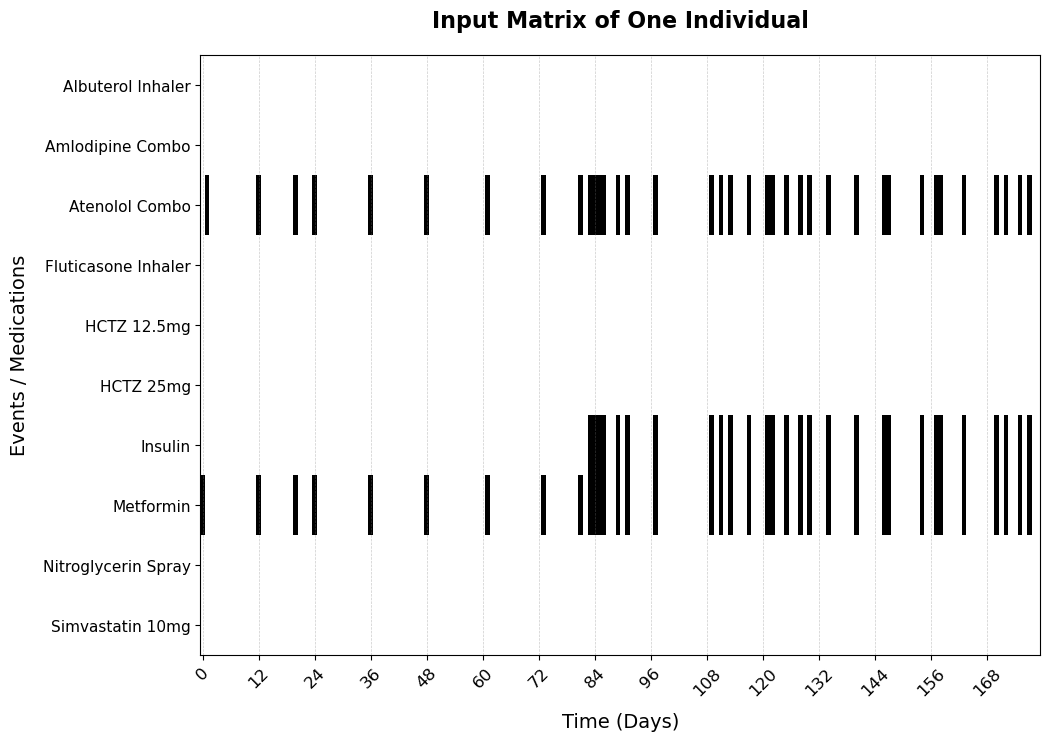

In [12]:
#Nombre d'événements uniques par patient
events_per_patient = timed_event_structure.groupby('ID_PATIENT')['Event'].nunique()

# Au moins 3 événements différents
patients_complets = events_per_patient[events_per_patient >= 3].index.tolist()

patient_index = int(patients_complets[0])
print(f"Patient used for visualization : {patient_index}")
plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded, time_unit='Days')

The matrix for Patient No. 21 clearly illustrates the multidimensional nature of the data: multiple treatments can be active simultaneously at any given time. Here, for example, we see that in Day 84, the patient is receiving Atenolol Combo, Insulin and Metformin at the same time.

## 4. Exploring SWoTTeD Hyperparameters

The values of $\alpha$ and $\gamma$ are calculated from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ using `compute_normalized_reg_terms`. Before running the simulations, we display the corresponding actual values to ensure they are within a reasonable order of magnitude.

We randomly sample 10 configurations from the hyperparameter space defined by $R \in \{3, 4, 5, 6, 7, 8, 9\}$, $\omega \in \{7, 10, 14, 21\}$, $\tilde{\alpha} \in \{10^{-5}, 10^{-4}, 2\times10^{-4}\}$, and $\tilde{\gamma} \in \{0.1, 0.5, 2.0\}$. 

For each configuration, we record $\text{FIT}_X$ and $\text{div}(\mathcal{P})$. The best model state is saved for each run via the checkpoint mechanism, and all results are aggregated into a DataFrame sorted by descending $\text{FIT}_X$, then by descending $\text{div}(\mathcal{P})$.

In [13]:
K = tca.analyzer.K
T = tca.analyzer.T
N = tca.analyzer.N

for R in [3, 5, 7]:
    for omega in [7, 14, 30]:
        facteur_alpha = (K * T) / (R * omega)
        facteur_gamma = N / R
        print(f"R={R}, ω={omega} → facteur_α={facteur_alpha:.0f}, facteur_γ={facteur_gamma:.2f}")

R=3, ω=7 → facteur_α=7723, facteur_γ=3.33
R=3, ω=14 → facteur_α=3861, facteur_γ=3.33
R=3, ω=30 → facteur_α=1802, facteur_γ=3.33
R=5, ω=7 → facteur_α=4634, facteur_γ=2.00
R=5, ω=14 → facteur_α=2317, facteur_γ=2.00
R=5, ω=30 → facteur_α=1081, facteur_γ=2.00
R=7, ω=7 → facteur_α=3310, facteur_γ=1.43
R=7, ω=14 → facteur_α=1655, facteur_γ=1.43
R=7, ω=30 → facteur_α=772, facteur_γ=1.43


In [14]:
for R in [3, 5, 7]:
    for omega in [7, 14, 30]:
        for alpha_rel, gamma_rel in [(1e-5, 0.1), (1e-4, 0.5), (2e-4, 2.0)]:
            a, g = compute_normalized_reg_terms(K, T, N, R=R, omega=omega,
                                                alpha_rel=alpha_rel, gamma_rel=gamma_rel)
            print(f"R={R}, ω={omega}, α_rel={alpha_rel} → α={a:.4f}, γ={g:.4f}")

R=3, ω=7, α_rel=1e-05 → α=0.0772, γ=0.3333
R=3, ω=7, α_rel=0.0001 → α=0.7723, γ=1.6667
R=3, ω=7, α_rel=0.0002 → α=1.5446, γ=6.6667
R=3, ω=14, α_rel=1e-05 → α=0.0386, γ=0.3333
R=3, ω=14, α_rel=0.0001 → α=0.3861, γ=1.6667
R=3, ω=14, α_rel=0.0002 → α=0.7723, γ=6.6667
R=3, ω=30, α_rel=1e-05 → α=0.0180, γ=0.3333
R=3, ω=30, α_rel=0.0001 → α=0.1802, γ=1.6667
R=3, ω=30, α_rel=0.0002 → α=0.3604, γ=6.6667
R=5, ω=7, α_rel=1e-05 → α=0.0463, γ=0.2000
R=5, ω=7, α_rel=0.0001 → α=0.4634, γ=1.0000
R=5, ω=7, α_rel=0.0002 → α=0.9267, γ=4.0000
R=5, ω=14, α_rel=1e-05 → α=0.0232, γ=0.2000
R=5, ω=14, α_rel=0.0001 → α=0.2317, γ=1.0000
R=5, ω=14, α_rel=0.0002 → α=0.4634, γ=4.0000
R=5, ω=30, α_rel=1e-05 → α=0.0108, γ=0.2000
R=5, ω=30, α_rel=0.0001 → α=0.1081, γ=1.0000
R=5, ω=30, α_rel=0.0002 → α=0.2162, γ=4.0000
R=7, ω=7, α_rel=1e-05 → α=0.0331, γ=0.1429
R=7, ω=7, α_rel=0.0001 → α=0.3310, γ=0.7143
R=7, ω=7, α_rel=0.0002 → α=0.6620, γ=2.8571
R=7, ω=14, α_rel=1e-05 → α=0.0165, γ=0.1429
R=7, ω=14, α_rel=0.0001 → α

Les facteurs de normalisation étant très grands pour $\alpha$ (entre 772 et 7723 selon la configuration), la plage explorable pour $\tilde{\alpha}$ est restreinte à $[10^{-5}, 2 \times 10^{-4}]$, ce qui correspond à des valeurs réelles de $\alpha$ comprises entre 0.01 et 1.5. Pour $\gamma$, le facteur $N/R$ variant entre 1.43 et 3.33, la plage $\tilde{\gamma} \in [0.1, 2.0]$ donne des valeurs réelles de $\gamma$ comprises entre 0.1 et 6.67, suffisamment large pour couvrir des régularisation faibles à fortes.

In [15]:
random.seed(42)
np.random.seed(42)

sampled_configs = [
    (
        random.randint(2, 5),
        random.randint(2, 10),
        float(np.exp(random.uniform(np.log(1e-5), np.log(2e-4)))),
        float(np.exp(random.uniform(np.log(0.1),  np.log(2.0)))),
    )
    for _ in range(10)
]

all_results = []

for rank, twl, alpha_rel, gamma_rel in sampled_configs:
    alpha, gamma = compute_normalized_reg_terms(
        K=K, T=T, N=N,
        R=rank, omega=twl,
        alpha_rel=alpha_rel,
        gamma_rel=gamma_rel,
    )

    print(f"\nRunning trial with rank={rank}, twl={twl}, alpha_rel={alpha_rel:.5f}, gamma_rel={gamma_rel:.5f} "
              f"→ alpha={alpha:.5f}, gamma={gamma:.5f} ...")
    result = run_swotted_trial(
        timed_event_structure,
        rank=rank, time_window_length=twl,
        reg_ns=gamma, reg_s=alpha,
        lr=1e-2, n_epochs=500,
        early_stopping=True,
        fit_metric_every_n_epochs=10,
        early_stopping_patience=5,
    )
    
    result['alpha_rel'] = alpha_rel
    result['gamma_rel'] = gamma_rel

    Ph_tensor = result['tca_trial'].analyzer.model.Ph.detach()
    div_cos, _ = phenotype_diversity(Ph_tensor)

    result['div_cos'] = div_cos

    all_results.append(result)

results_df = (pd.DataFrame(all_results)
                .sort_values(by=['final_fit_metric', 'div_cos'], ascending=[False, False])
                .reset_index(drop=True))

display(results_df.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



Running trial with rank=2, twl=2, alpha_rel=0.00009, gamma_rel=0.20826 → alpha=3.73867, gamma=1.04131 ...

rank=2, twl=2, reg_ns=1.0413138669343607, reg_s=3.7386666867991103, learning_rate=0.01
Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 11382.655273 - train_loss_W: 18068.673828 - train_loss_total: 29451.329102 - duration: 2.84s - FIT metric: 0.0848 - ||P||_1: 51.9426 - S(X): 0.3941
    early stopping: Metric fit_metric initialized at 0.085.
    checkpoint: New best FIT metric = 0.0848 at epoch 1.
    lr_scheduler: learning rate = 1.00e-02
Epoch 2/500 : - train_loss_Ph: 9044.076172 - train_loss_W: 15496.076172 - train_loss_total: 24540.152344 - duration: 2.53s - ||P||_1: 35.6683 - S(X): 0.5178
    lr_scheduler: learning rate = 1.00e-02
Epoch 3/500 : - train_loss_Ph: 6495.837891 - train_loss_W: 12700.875977 - train_loss_total: 19196.713867 - duration: 2.53s - ||P||_1: 21.6032 - S(X): 0.8592
    lr_scheduler: learning rate = 1.00e-02
Epoch 4/500 : - train_loss_Ph: 3733.198486 - train_loss_W: 9719.638672 - train_loss_total: 13452.837158 - duration: 2.73s - ||P||_1: 9.9126 - S(X): 2.2331
    lr_scheduler: learning rate = 1.00e-02
Epoch 5/500 : - train_loss_Ph: 1382.968872 - train_loss_W: 7253

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,final_p_l1_norm,final_non_succession,elapsed_s,alpha_rel,gamma_rel,div_cos
0,5,5,0.460219,0.249168,0.01,150,0.586544,100,0.588509,5.657970,544.069275,7038.09,0.000038,0.230109,0.919030
1,3,5,0.913689,1.902256,0.01,150,0.556838,100,0.562562,7.448022,227.651413,6799.59,0.000176,0.274107,0.906001
2,2,8,0.662019,0.111488,0.01,160,0.555847,110,0.556855,7.992379,319.582458,7237.92,0.000011,0.132404,1.000000
3,4,2,1.246203,1.804306,0.01,160,0.543626,110,0.544302,7.299740,79.194733,7321.94,0.000089,0.498481,0.998015
4,5,3,2.399442,0.565103,0.01,170,0.532059,120,0.542159,6.906262,49.152023,8050.75,0.000052,1.199721,0.999747
5,3,3,4.826487,1.368236,0.01,200,0.527753,160,0.538848,5.546272,16.875299,8843.63,0.000076,1.447946,0.739464
6,3,10,1.790917,0.328186,0.01,160,0.440353,110,0.441382,7.505510,139.866547,7293.24,0.000061,0.537275,0.972476
7,2,8,6.332652,0.135428,0.01,170,0.378666,120,0.386446,7.352816,6.424995,7695.72,0.000013,1.266530,0.516842
8,2,4,1.385626,1.641374,0.01,170,0.364561,120,0.365583,6.165376,43.448826,7490.96,0.000081,0.277125,0.957544
9,2,2,1.041314,3.738667,0.01,150,0.361713,100,0.362261,4.516140,35.902565,6774.89,0.000092,0.208263,1.000000


=== Meilleure configuration ===
rank      : 5
twl       : 5
alpha_rel : 3.84e-05
gamma_rel : 2.30e-01
alpha     : 2.49e-01
gamma     : 4.60e-01
FIT_X     : 0.5865
div_cos  : 0.9190


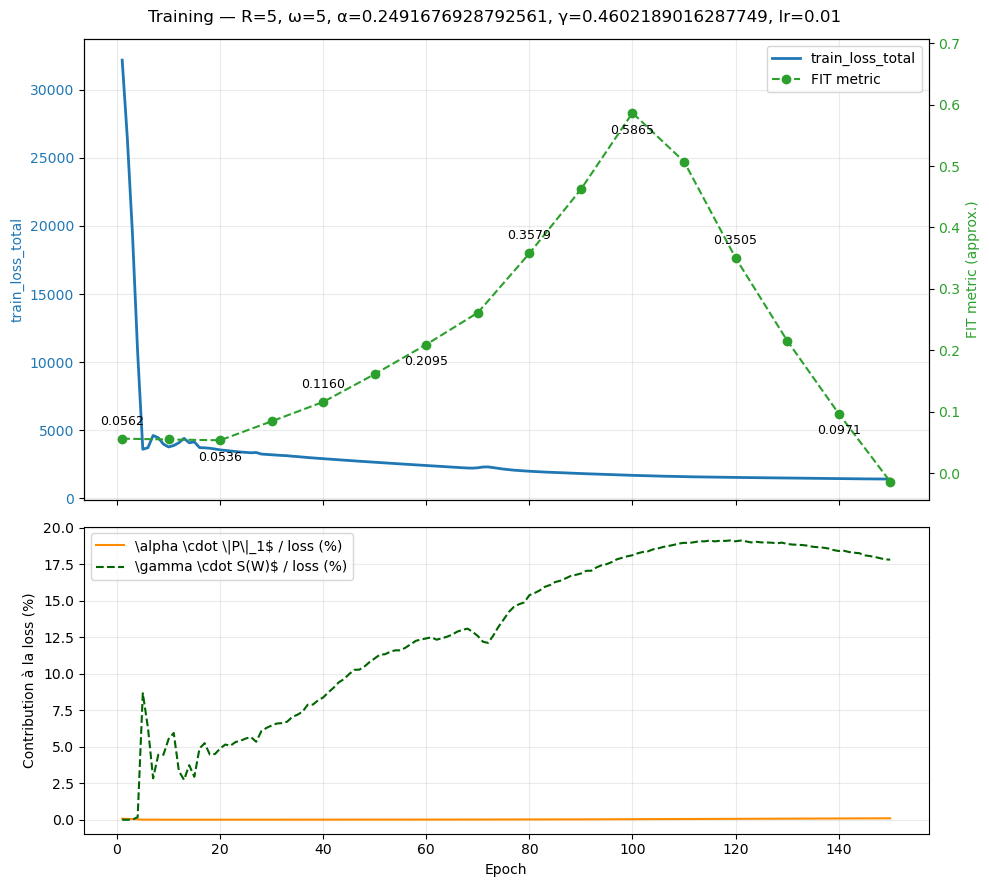

Decomposed into 901 pathways with rank 5 and time window length 5
Success rate for the entire dataset: 0.5882


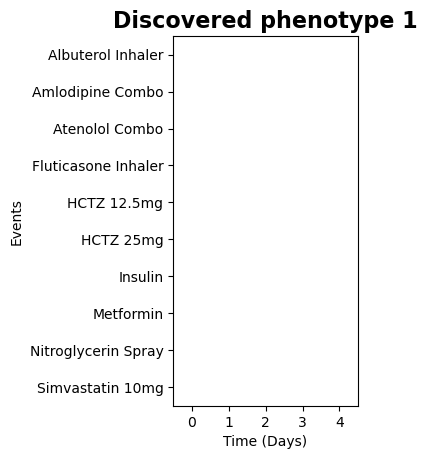

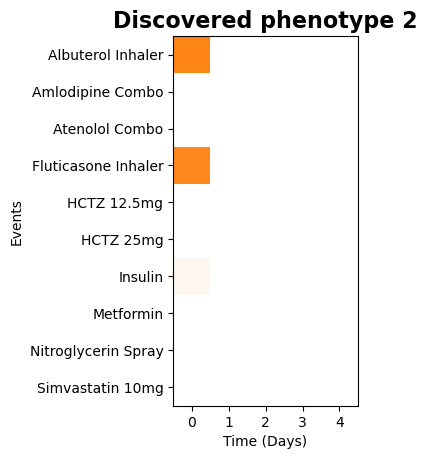

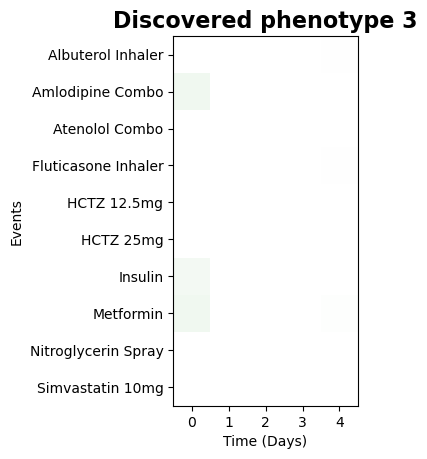

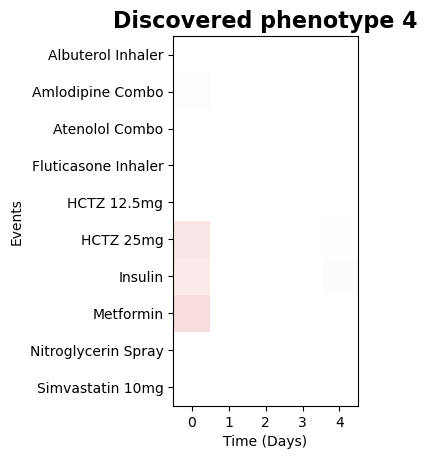

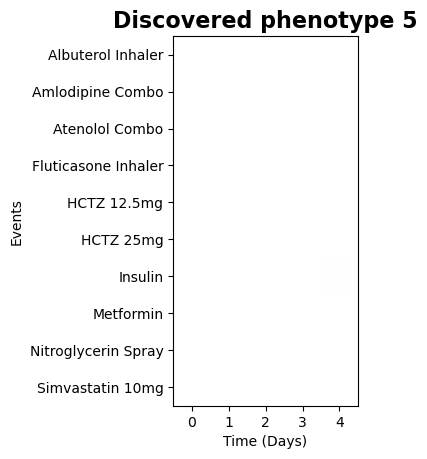

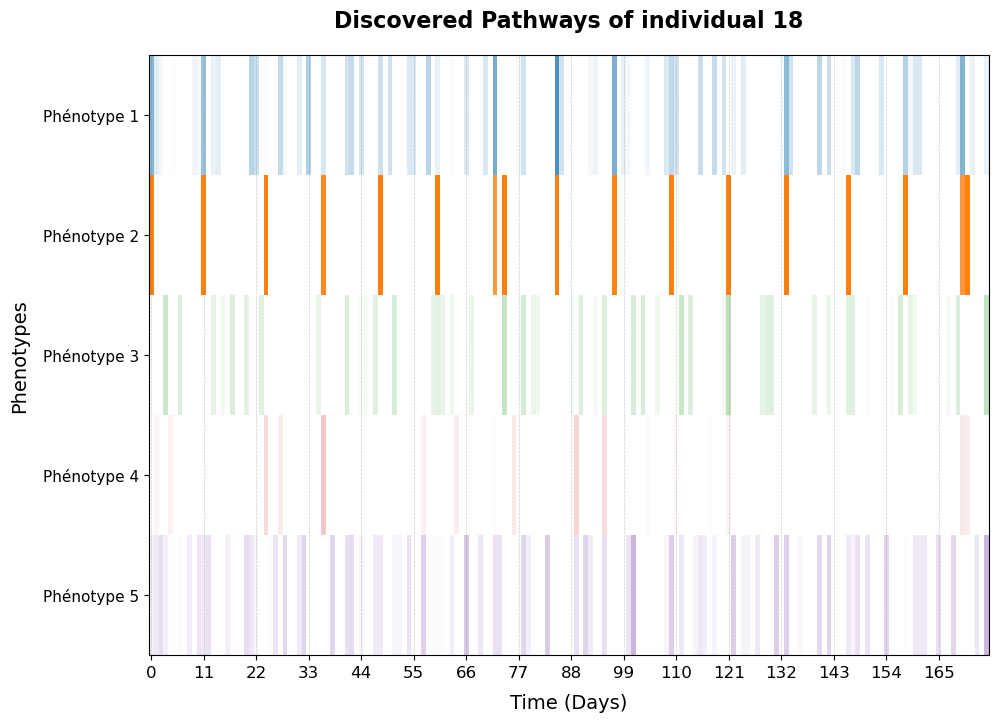

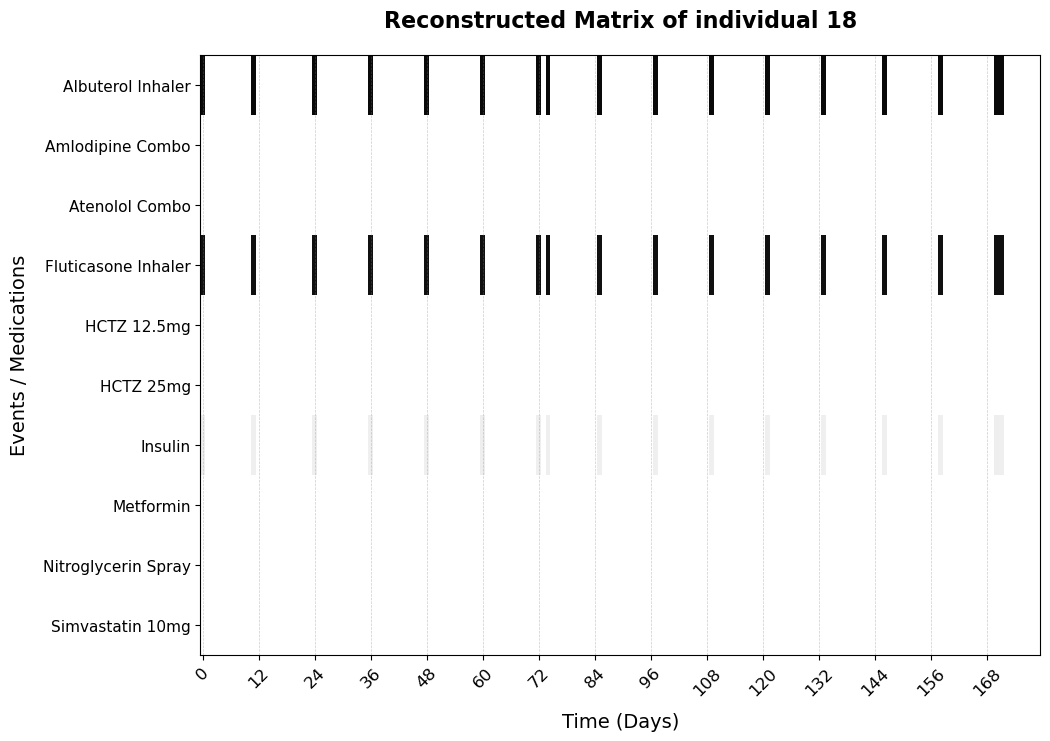

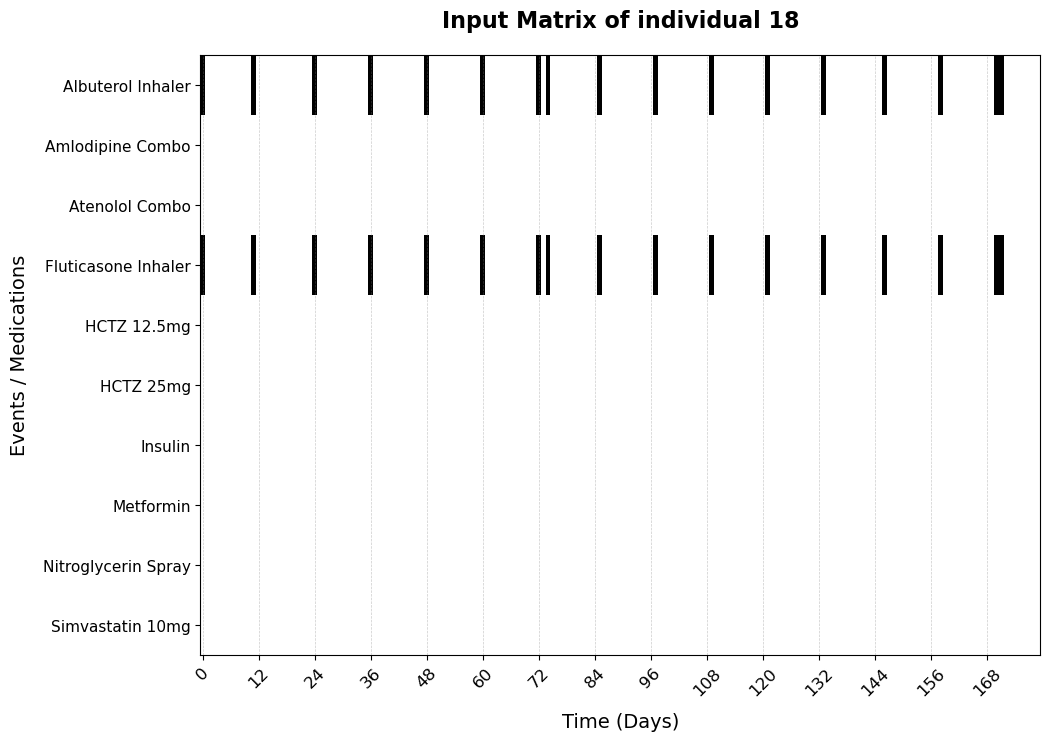

In [16]:
best = results_df.iloc[0]

print("=== Meilleure configuration ===")
print(f"rank      : {best['rank']}")
print(f"twl       : {best['time_window_length']}")
print(f"alpha_rel : {best['alpha_rel']:.2e}")
print(f"gamma_rel : {best['gamma_rel']:.2e}")
print(f"alpha     : {best['reg_term_s']:.2e}")
print(f"gamma     : {best['reg_term_ns']:.2e}")
print(f"FIT_X     : {best['best_fit_metric']:.4f}")
print(f"div_cos  : {best['div_cos']:.4f}")

plot_training_history(best)


best['tca_trial'].analyzer.get_decomposition_results(
    labels=name_events, id=18, time_unit="Days"
)

Decomposed into 901 pathways with rank 5 and time window length 5
Success rate for the entire dataset: 0.5882


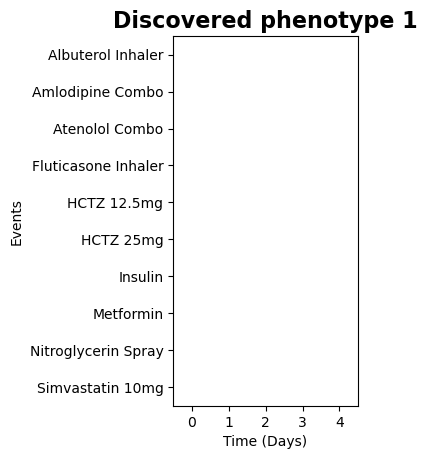

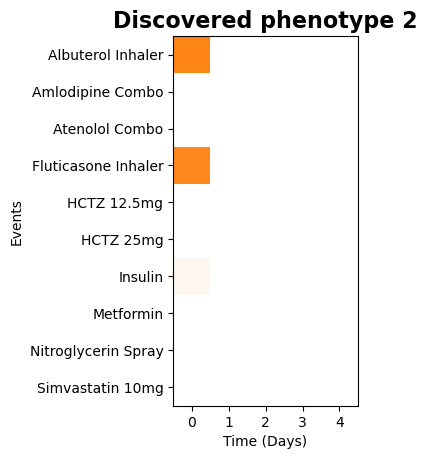

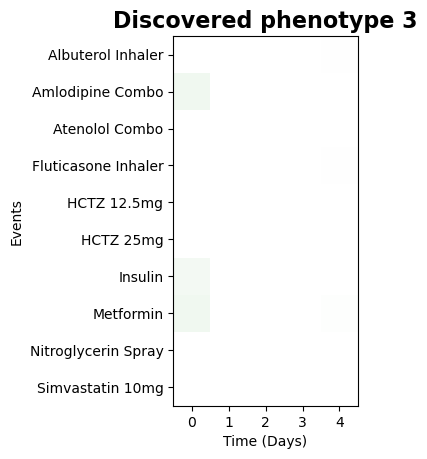

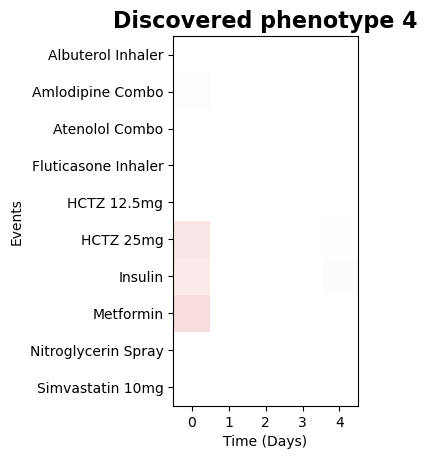

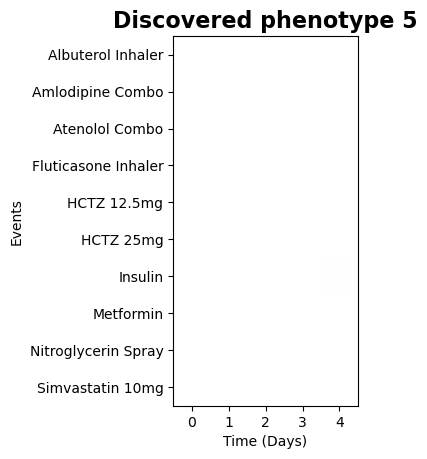

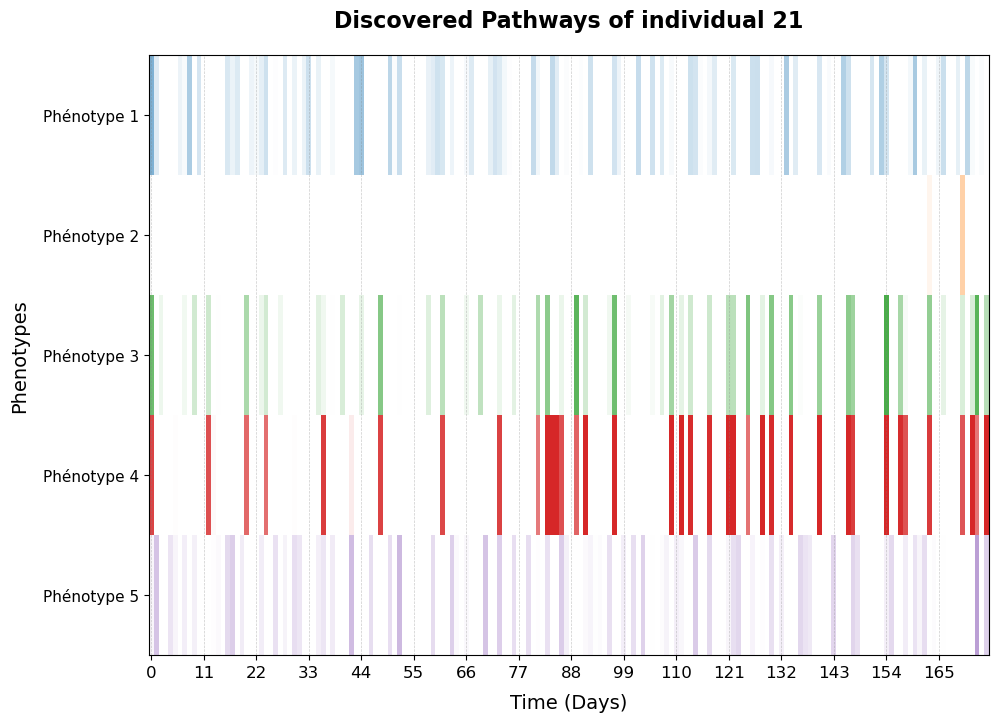

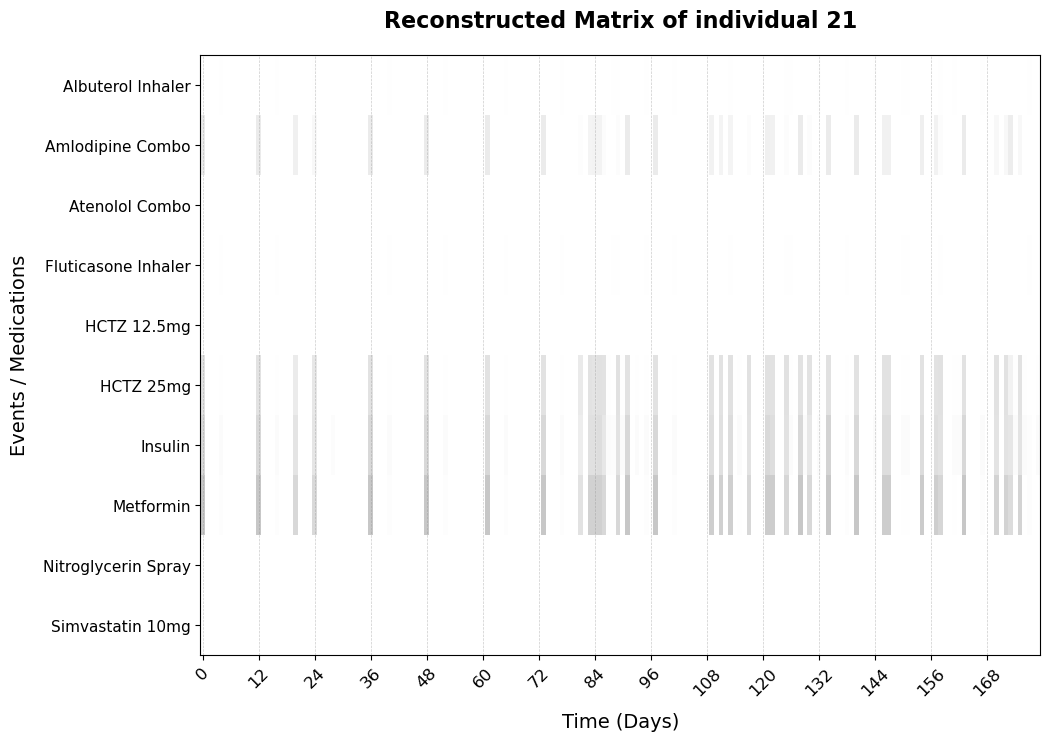

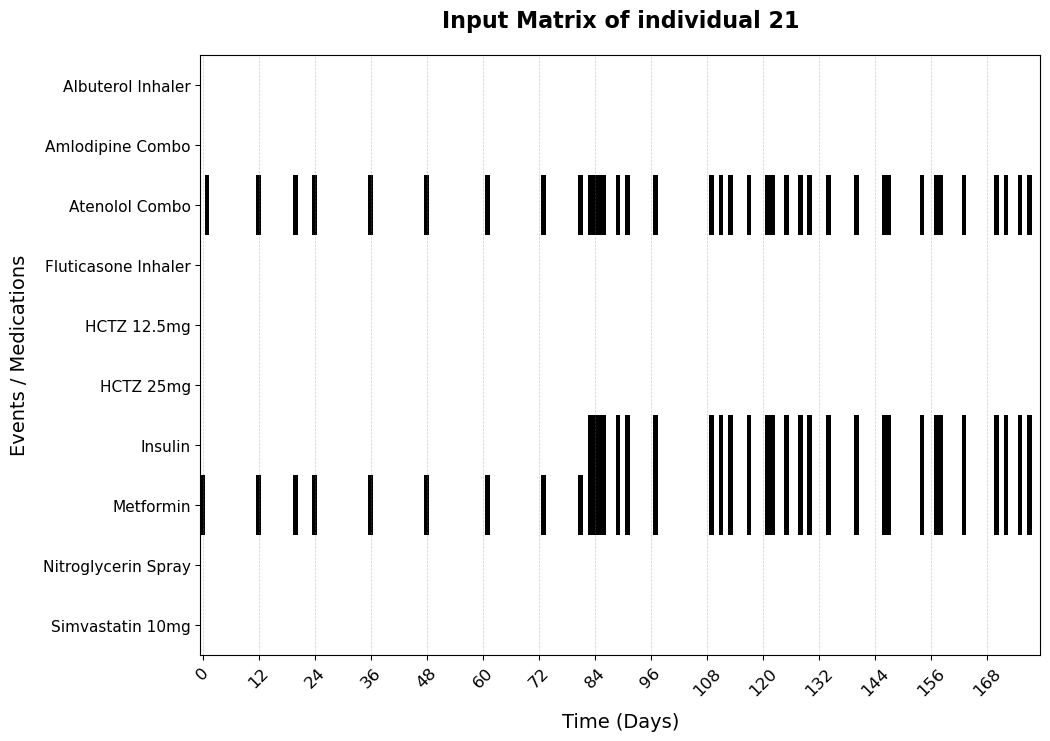

In [17]:
best['tca_trial'].analyzer.get_decomposition_results(
    labels=name_events, id=21, time_unit="Days"
)

Reconstruction quality varies depending on the patient's medication profile.
Patients whose trajectory is dominated by Albuterol Inhaler and Fluticasone Inhaler (captured by Phenotype 2) are better reconstructed than those with more complex polypharmacy profiles. We compute below the number of patients who received both medications at least once during their follow-up.

## 5. Clustering Based on Phenotype Intensities

The ultimate goal of the SWoTTeD decomposition is to group patients into clinically interpretable clusters. Once the phenotypes have been learned, each patient $k$ is summarized by an intensity vector of size $R$, obtained by summing the activations of their matrix $W^{(k)}$ over the entire follow-up period and then normalizing the result. Clustering is applied to this compact representation.

In [18]:
from sklearn.preprocessing import MinMaxScaler

best_tca = best['tca_trial']

ph_intensity = best_tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler(feature_range=(0, 1)))
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (901, 6)


,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4,Phenotype_5,ID_PATIENT
0,0.267300,0.801482,0.001737,0.001079,0.169036,1
1,0.418663,0.839861,0.002598,0.000860,0.085383,2
2,0.365149,0.001438,0.211739,0.280095,0.564222,3
3,0.466900,0.759370,0.014947,0.000584,0.058330,4
4,0.240549,0.001776,0.082621,0.229886,0.306646,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


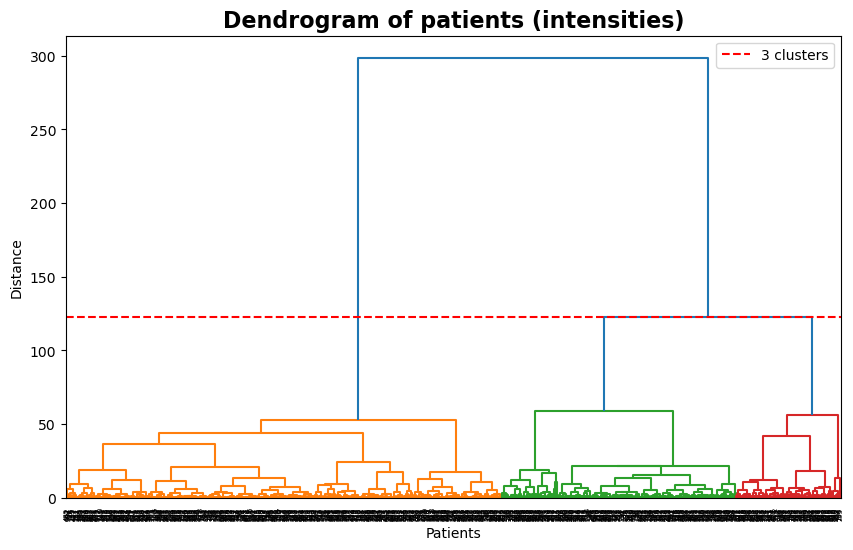

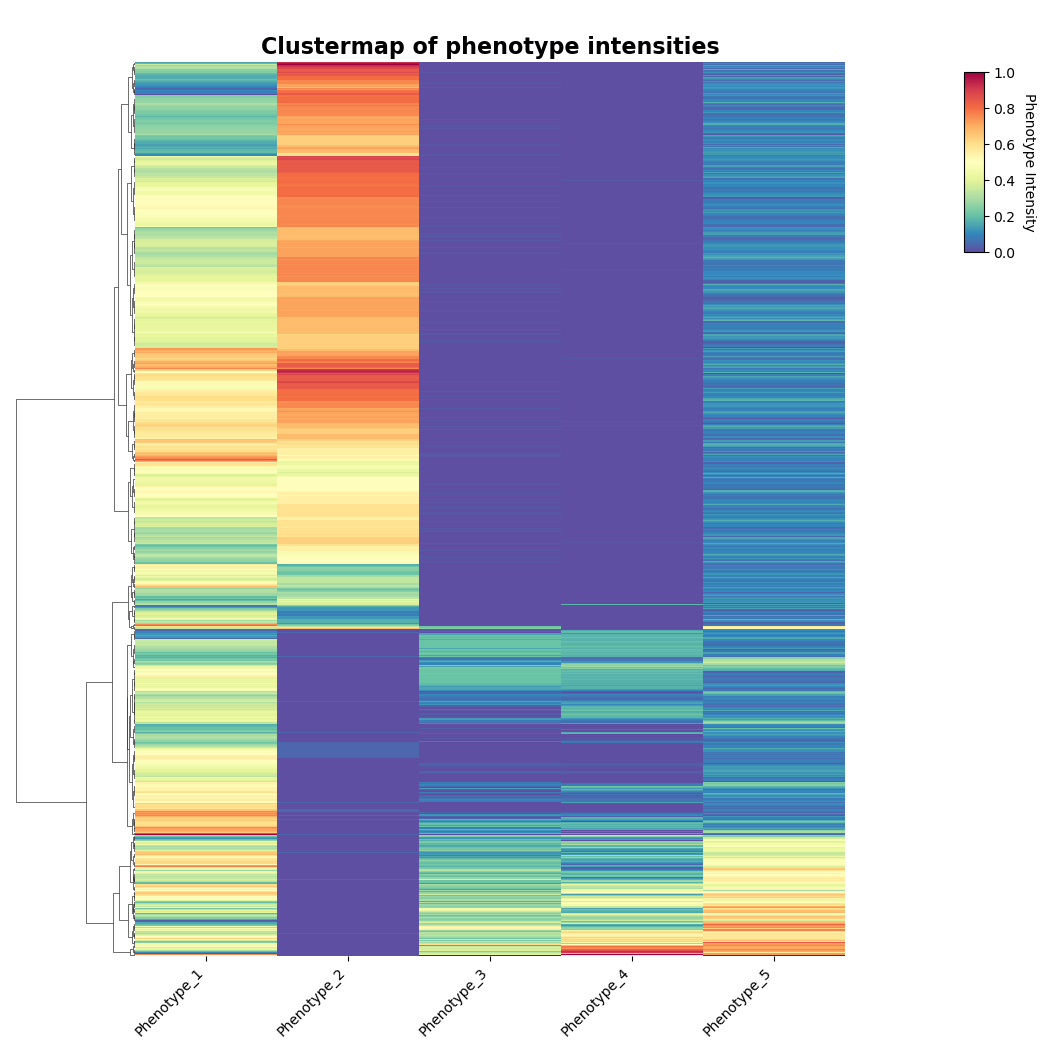

In [19]:
distance_matrix = best_tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = best_tca.hierarchical_clustering(distance_matrix)

best_tca.plot_dendrogram(linkage_matrix, title='Dendrogram of patients (intensities)', n_clusters=3)
best_tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap of phenotype intensities')

Effectifs par cluster:
1    506
2    273
3    122
Name: count, dtype: int64


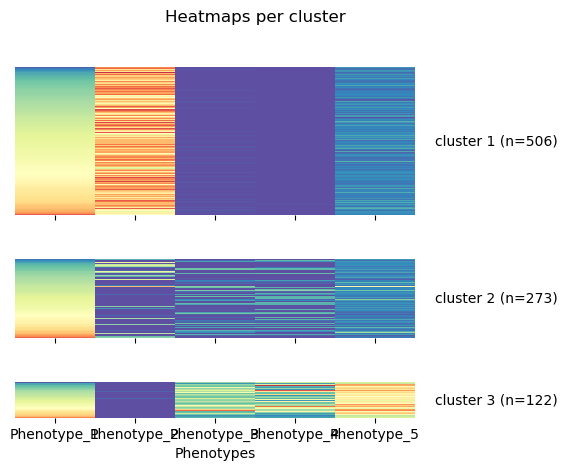

In [20]:
clusters = best_tca.assign_clusters(linkage_matrix, num_clusters=3)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

best_tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps per cluster')